In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostClassifier
from imblearn.over_sampling import ADASYN
from imblearn.pipeline import Pipeline as imbPipeline
from feature_engine import encoding as ce
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.under_sampling import RandomUnderSampler 
from scipy.stats import randint,uniform

In [62]:
df=pd.read_csv('train_apps.csv',sep=',')
df.head()

,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,...,overdraft_app_term_max_360,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea,target_value
0,127345,2024-02-01,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lombard,NaN,0
1,127209,2024-02-01,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0.842771,NaN,NaN,...,NaN,NaN,NaN,-0.862289,-3.400318,-0.780786,NaN,inn_scoring,NaN,0
2,272776,2024-02-01,2.185431,3.167063,2.369547,-0.709770,-0.400695,0.000000,0.834373,4.897257,...,NaN,NaN,NaN,1.168810,3.015012,0.554064,NaN,NaN,NaN,0
3,127210,2024-02-01,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,164500,2024-02-01,0.845440,4.559196,3.467730,-2.484194,-0.400695,0.000000,-0.518122,-3.435251,...,NaN,1.067447,NaN,1.022327,1.506380,0.190096,NaN,NaN,NaN,0


In [63]:
df.shape

(145241, 28)

<Axes: xlabel='sum_deb_investment_90', ylabel='Count'>

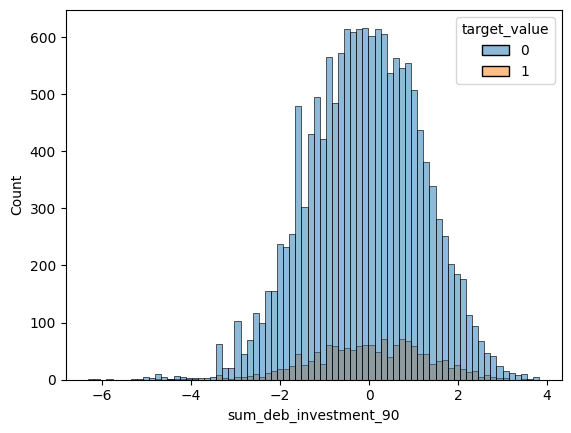

In [64]:
sns.histplot(data=df,x='sum_deb_investment_90',hue='target_value')

<Axes: xlabel='db_group_last', ylabel='Count'>

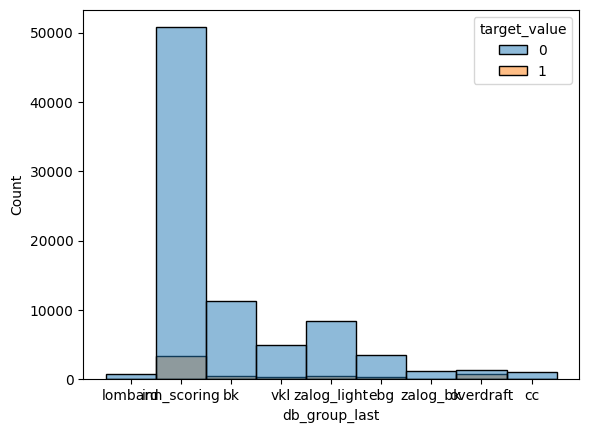

In [65]:
sns.histplot(data=df,x='db_group_last',hue='target_value')

In [66]:
df['sum_deb_investment_90'].describe()

count    16544.000000
mean        -0.094382
std          1.270767
min         -6.316172
25%         -0.948789
50%         -0.065987
75%          0.817189
max          3.823178
Name: sum_deb_investment_90, dtype: float64

<Axes: xlabel='count_all_corp_dashboard_events', ylabel='Count'>

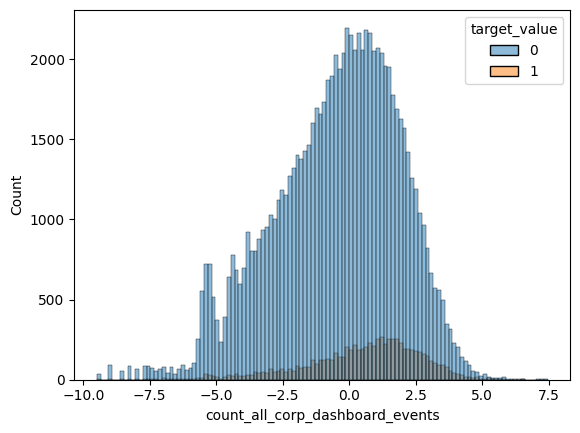

In [67]:
sns.histplot(data=df,x='count_all_corp_dashboard_events',hue='target_value')

In [68]:
df.isnull().sum()

front_id                                  0
decision_day                              0
loan_amount_last                          0
overdraft_limit_min                       0
overdraft_limit_max                       0
offered_rate                              0
cb_rate                                   0
corp_credit_products                  51188
sum_deb_ul_90                         54111
sum_deb_ul_30                         61453
cnt_deb_loan_90                       31458
cnt_deb_ul_ip_90                      30305
cnt_deb_ul_ip_30                      33373
balance_rur_amt_30_min                34826
cnt_cred_loan_90                      31458
loan_rev_max_start_non_fin           132635
loan_rev_min_start_fin               124706
app_term_mean_360                     55883
overdraft_app_term_max_360           139732
days_from_authperson_registration     78473
fl_hdb_bki_total_active_products      24368
corp_list                             51188
count_all_corp_dashboard_events 

count    110415.000000
mean         -0.355605
std           3.284146
min          -5.561599
25%          -2.550149
50%           0.001776
75%           2.120235
max           8.483646
Name: balance_rur_amt_30_min, dtype: float64

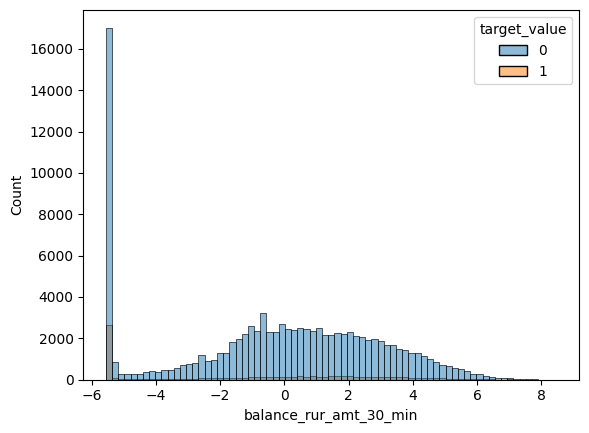

In [69]:
sns.histplot(data=df,x='balance_rur_amt_30_min',hue='target_value')
df['balance_rur_amt_30_min'].describe()

<Axes: xlabel='db_group_last', ylabel='overdraft_app_term_max_360'>

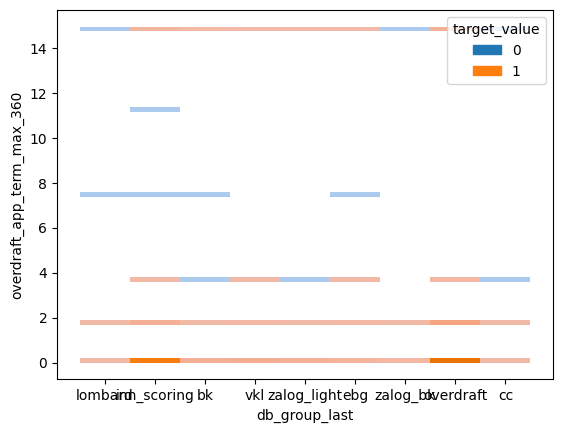

In [70]:
sns.histplot(data=df,x='db_group_last',y='overdraft_app_term_max_360',hue='target_value')


In [71]:
df_overdraft = df.loc[df['db_group_last'] == 'overdraft',['overdraft_app_term_max_360']]
df_overdraft.describe()
df_overdraft.value_counts()

overdraft_app_term_max_360
0.000000                      1274
1.869090                       466
14.952721                      328
3.738180                        44
Name: count, dtype: int64

In [72]:
df['balance_rur_amt_30_min'].describe()

count    110415.000000
mean         -0.355605
std           3.284146
min          -5.561599
25%          -2.550149
50%           0.001776
75%           2.120235
max           8.483646
Name: balance_rur_amt_30_min, dtype: float64

In [73]:
df['balance_rur_amt_30_min_flag']=df['balance_rur_amt_30_min'].isna().astype(int)
df['balance_rur_amt_30_min']=df['balance_rur_amt_30_min'].fillna(0)
df

,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,...,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea,target_value,balance_rur_amt_30_min_flag
0,127345,2024-02-01,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,lombard,NaN,0,0
1,127209,2024-02-01,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0.842771,NaN,NaN,...,NaN,NaN,-0.862289,-3.400318,-0.780786,NaN,inn_scoring,NaN,0,0
2,272776,2024-02-01,2.185431,3.167063,2.369547,-0.709770,-0.400695,0.000000,0.834373,4.897257,...,NaN,NaN,1.168810,3.015012,0.554064,NaN,NaN,NaN,0,0
3,127210,2024-02-01,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,164500,2024-02-01,0.845440,4.559196,3.467730,-2.484194,-0.400695,0.000000,-0.518122,-3.435251,...,1.067447,NaN,1.022327,1.506380,0.190096,NaN,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145236,258918,2025-06-05,1.339991,2.480726,1.828130,3.903733,1.602779,0.000000,0.893285,5.247350,...,2.592372,1.302069,2.628996,1.589065,0.706500,NaN,zalog_light,Новосибирская область,0,0
145237,176413,2025-06-05,0.845440,3.639458,3.605443,1.596982,1.602779,1.229059,0.576790,2.776671,...,-0.384331,-4.700790,1.214168,0.665258,0.306940,NaN,inn_scoring,г. Москва,0,0
145238,258920,2025-06-05,1.690880,3.960429,2.995393,3.903733,1.602779,1.234158,0.691625,4.440577,...,1.834869,-1.351879,1.806117,2.272156,0.647315,NaN,inn_scoring,г. Санкт - Петербург,0,0
145239,174837,2025-06-05,0.845440,-2.742346,-2.292086,2.661636,1.602779,1.541025,0.109289,0.918909,...,-1.594352,1.674455,1.050198,-0.305594,0.394573,-0.105689,inn_scoring,Красноярский край,0,0


In [74]:
df['decision_day'].head(20)

0     2024-02-01
1     2024-02-01
2     2024-02-01
3     2024-02-01
4     2024-02-01
5     2024-02-01
6     2024-02-01
7     2024-02-01
8     2024-02-01
9     2024-02-01
10    2024-02-01
11    2024-02-01
12    2024-02-01
13    2024-02-01
14    2024-02-01
15    2024-02-01
16    2024-02-01
17    2024-02-01
18    2024-02-01
19    2024-02-01
Name: decision_day, dtype: object

In [75]:
df['decision_day'] = pd.to_datetime(df['decision_day'],errors='coerce')

In [76]:
df['decision_day_flag'] = (df['decision_day'].dt.day >= 25).astype(int)
df['decision_weekend'] = (df['decision_day'].dt.dayofweek >= 5).astype(int)

In [77]:
df['decision_weekend'].value_counts()

decision_weekend
0    142018
1      3223
Name: count, dtype: int64

In [78]:
df['decision_day_flag'].value_counts()

decision_day_flag
0    113770
1     31471
Name: count, dtype: int64

In [79]:
df['decision_day'].unique()

<DatetimeArray>
['2024-02-01 00:00:00', '2024-02-02 00:00:00', '2024-02-03 00:00:00',
 '2024-02-04 00:00:00', '2024-02-05 00:00:00', '2024-02-06 00:00:00',
 '2024-02-07 00:00:00', '2024-02-08 00:00:00', '2024-02-09 00:00:00',
 '2024-02-10 00:00:00',
 ...
 '2025-05-27 00:00:00', '2025-05-28 00:00:00', '2025-05-29 00:00:00',
 '2025-05-30 00:00:00', '2025-05-31 00:00:00', '2025-06-01 00:00:00',
 '2025-06-02 00:00:00', '2025-06-03 00:00:00', '2025-06-04 00:00:00',
 '2025-06-05 00:00:00']
Length: 485, dtype: datetime64[ns]

In [80]:
df['count_all_corp_dashboard_events'] = df['count_all_corp_dashboard_events'].fillna(0)

In [81]:
df=pd.read_csv('train_apps.csv',sep=',')
df_feature=df.drop(columns=['target_value'],axis=1)
df_feature['cnt_deb_ul_ip_90'] = df_feature['cnt_deb_ul_ip_90'].fillna(df_feature['cnt_deb_ul_ip_90'].median())
df_feature['cnt_cred_loan_90_flag']=df_feature['cnt_cred_loan_90'].isna().astype(int)
df_feature['cnt_cred_loan_90'] = df_feature['cnt_cred_loan_90'].fillna(df_feature['cnt_cred_loan_90'].median())
df_feature['fl_hdb_bki_total_active_products'] = df_feature['fl_hdb_bki_total_active_products'].fillna(df_feature['fl_hdb_bki_total_active_products'].median())
df_feature['balance_rur_amt_30_min_flag']=df_feature['balance_rur_amt_30_min'].isna().astype(int)
df_feature['balance_rur_amt_30_min']=df_feature['balance_rur_amt_30_min'].fillna(0)

In [82]:
df_feature['offered_rate'] = df_feature['offered_rate'].mask(df_feature['offered_rate'] < -50,-9999)
df_feature['offered_rate'] = df_feature['offered_rate'].mask(df_feature['offered_rate'] > 50,9999)

In [83]:
df_feature['decision_day'] = pd.to_datetime(df_feature['decision_day'],errors='coerce')
df_feature['decision_day_flag'] = (df_feature['decision_day'].dt.day >= 25).astype(int)
df_feature['decision_weekend'] = (df_feature['decision_day'].dt.dayofweek >= 5).astype(int)
df_feature['count_all_corp_dashboard_events'] = df_feature['count_all_corp_dashboard_events'].fillna(0)

In [84]:
df_feature=df_feature.drop(columns=['front_id','decision_day',
                                    'corp_credit_products','sum_deb_ul_90',
                                    'sum_deb_ul_30','cnt_deb_loan_90',
                                    'sum_deb_ul_90','cnt_deb_ul_ip_30',
                                    'loan_rev_max_start_non_fin','loan_rev_min_start_fin',
                                    'app_term_mean_360','overdraft_app_term_max_360','days_from_authperson_registration',
                                    'corp_list',
                                    'p75_time_spent_minutes','sum_deb_investment_90'],axis=1)

In [85]:
# param_grid = {
#     'model__learning_rate': [0.01, 0.05, 0.1],
#     'model__n_estimators': [300, 500, 800],
#     'model__max_depth': [2, 3, 4],
#     'model__subsample': [0.6, 0.8, 1.0],
#     'model__max_features': ['sqrt', 'log2']
# }
# num_features = [
#     'loan_amount_last','overdraft_limit_min',
#     'overdraft_limit_max','offered_rate',
#     'cb_rate','cnt_deb_ul_ip_90','balance_rur_amt_30_min',
#     'cnt_cred_loan_90','fl_hdb_bki_total_active_products','count_all_corp_dashboard_events'
# ]

# cat_features = [
#     'fl_adminarea','db_group_last'
# ]
# flag_features = [
#     'balance_rur_amt_30_min_flag',
#     'cnt_cred_loan_90_flag',
#     'decision_day_flag',
#     'decision_weekend'
# ]

# X = df_feature[num_features + cat_features + flag_features]
# y = df['target_value']

# preprocess = ColumnTransformer([
#     ('num', StandardScaler(), num_features),
#     ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
#     ('flag', 'passthrough', flag_features)
# ])

# pipe = Pipeline([
#     ('prep', preprocess),
#     ('model', GradientBoostingClassifier(subsample=0.6,
#     n_estimators=200,
#     max_features='sqrt',
#     max_depth=3,
#     loss='exponential',
#     learning_rate=0.2,verbose=2
#     ))
# ])
# sample_weights = compute_sample_weight('balanced', y)
# grid = RandomizedSearchCV(
#     pipe,
#     param_distributions=param_grid,
#     cv=5,
#     scoring='roc_auc',
#     n_jobs=3,
#     verbose=2
# )
# # oversampling = ADASYN(
# #     sampling_strategy='auto', # samples only the minority class
# #         random_state=0,
# #         n_neighbors=5,
# #         n_jobs=1)

# # X_resampled, y_resampled = oversampling.fit_resample(X_train, y_train)

# pipe.fit(X,y)
# y_prod_fit=pipe.predict_proba(X)[:, 1]
# roc_auc_score(y,y_prod_fit)
# work sample !!!!

In [86]:
# from sklearn.inspection import permutation_importance

# result = permutation_importance(pipe, X, y, n_repeats=5, random_state=42, scoring='roc_auc')
# imp = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)
# print(imp.head(15))

In [87]:
# param_grid = {
#     'model__learning_rate': [0.01, 0.05, 0.1],
#     'model__n_estimators': [300, 500, 800],
#     'model__max_depth': [2, 3, 4],
#     'model__subsample': [0.6, 0.8, 1.0],
#     'model__max_features': ['sqrt', 'log2']
# }
# num_features = [
#     'loan_amount_last','overdraft_limit_min',
#     'overdraft_limit_max','offered_rate',
#     'cb_rate','cnt_deb_ul_ip_90','balance_rur_amt_30_min',
#     'cnt_cred_loan_90','fl_hdb_bki_total_active_products','count_all_corp_dashboard_events'
# ]

# cat_features = [
#     'fl_adminarea','db_group_last'
# ]
# flag_features = [
#     'decision_weekend'
# ]

# X = df_feature[num_features + cat_features + flag_features]
# y = df['target_value']

# preprocess = ColumnTransformer([
#     ('num', StandardScaler(), num_features),
#     ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
#     ('flag', 'passthrough', flag_features)
# ])

# pipe = Pipeline([
#     ('prep', preprocess),
#     ('model', GradientBoostingClassifier(subsample=0.6,
#     n_estimators=200,
#     max_features='sqrt',
#     max_depth=3,
#     loss='exponential',
#     learning_rate=0.2,verbose=2
#     ))
# ])
# sample_weights = compute_sample_weight('balanced', y)
# grid = RandomizedSearchCV(
#     pipe,
#     param_distributions=param_grid,
#     cv=5,
#     scoring='roc_auc',
#     n_jobs=3,
#     verbose=2
# )
# # oversampling = ADASYN(
# #     sampling_strategy='auto', # samples only the minority class
# #         random_state=0,
# #         n_neighbors=5,
# #         n_jobs=1)

# # X_resampled, y_resampled = oversampling.fit_resample(X_train, y_train)

# pipe.fit(X,y)
# y_prod_fit=pipe.predict_proba(X)[:, 1]
# roc_auc_score(y,y_prod_fit)
# после удаления признаков 

In [88]:
# from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.metrics import roc_auc_score
# import numpy as np


# num_features = [
#     'loan_amount_last', 'overdraft_limit_min', 'overdraft_limit_max',
#     'offered_rate', 'cb_rate', 'cnt_deb_ul_ip_90', 'balance_rur_amt_30_min',
#     'cnt_cred_loan_90', 'fl_hdb_bki_total_active_products',
#     'count_all_corp_dashboard_events'
# ]
# cat_features = ['fl_adminarea', 'db_group_last']
# flag_features = ['decision_weekend']

# X = df_feature[num_features + cat_features + flag_features]
# y = df['target_value']


# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, stratify=y, test_size=0.2, random_state=42
# )


# preprocess = ColumnTransformer([
#     ('num', StandardScaler(), num_features),
#     ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
#     ('flag', 'passthrough', flag_features)
# ])


# model = GradientBoostingClassifier(
#     loss='log_loss',         
#     random_state=42,
#     validation_fraction=0.15, 
#     n_iter_no_change=15,      
#     tol=1e-4,
#     verbose=2                
# )

# pipe = Pipeline([
#     ('prep', preprocess),
#     ('model', model)
# ])

# param_grid = {
#     'model__learning_rate': [0.01, 0.05, 0.1],
#     'model__n_estimators': [300, 500, 800],
#     'model__max_depth': [2, 3, 4],
#     'model__subsample': [0.6, 0.8, 1.0],
#     'model__max_features': ['sqrt', 'log2'],
#     'model__min_samples_split': [10, 30, 50],
#     'model__min_samples_leaf': [5, 15, 30],
   
# }


# grid = RandomizedSearchCV(
#     pipe,
#     param_distributions=param_grid,
#     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
#     scoring='roc_auc',
#     n_jobs=3,               
#     verbose=2,
#     n_iter=30,               
#     random_state=42,
#     error_score='raise'
# )

# rus = RandomUnderSampler(random_state=42)
# X_res_rus, y_res_rus = rus.fit_resample(X_train,y_train)
# grid.fit(X_res_rus,y_res_rus)


# best_model = grid.best_estimator_
# y_pred = best_model.predict_proba(X_test)[:, 1]
# test_auc = roc_auc_score(y_test, y_pred)

# print(f"Лучшие параметры: {grid.best_params_}")
# print(f"Лучший средний ROC-AUC на кросс-валидации: {grid.best_score_:.4f}")
# print(f"ROC-AUC на тестовой выборке: {test_auc:.4f}")
# Рабочая модель

In [89]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
import numpy as np


num_features = [
    'loan_amount_last', 'overdraft_limit_min', 'overdraft_limit_max',
    'offered_rate', 'cb_rate', 'cnt_deb_ul_ip_90', 'balance_rur_amt_30_min',
    'cnt_cred_loan_90', 'fl_hdb_bki_total_active_products',
    'count_all_corp_dashboard_events'
]
cat_features = ['fl_adminarea', 'db_group_last']
flag_features = ['decision_weekend']

X = df_feature[num_features + cat_features + flag_features]
y = df['target_value']





preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ('flag', 'passthrough', flag_features)
])


model = xgb.XGBClassifier(
    objective='binary:logistic',
    learning_rate=0.1,     
    max_depth=6,            
    n_estimators=100,      
    subsample=0.8,          
    colsample_bytree=0.8,   
    reg_alpha=0.1,       
    reg_lambda=1,         
    gamma=0,              
    booster='gbtree',    
    tree_method='auto',    
    scale_pos_weight=1 ,
    verbosity=2            
)

pipe = Pipeline([
    ('prep', preprocess),
    ('model', model)
])

param_grid = {
    'model__n_estimators': randint(100, 1000),
    'model__max_depth': randint(2, 10),
    'model__learning_rate': uniform(0.01, 0.29),      
    'model__min_child_weight': randint(1, 15),
    'model__subsample': uniform(0.5, 0.5),            
    'model__colsample_bytree': uniform(0.5, 0.5),     
    'model__gamma': uniform(0, 5),
    'model__reg_lambda': uniform(0, 10),
    'model__reg_alpha': uniform(0, 5)
   
}


grid = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=3,               
    verbose=2,
    n_iter=30,               
    random_state=42,
    error_score='raise'
)

rus = RandomUnderSampler(random_state=42)
X_res_rus, y_res_rus = rus.fit_resample(X,y)
grid.fit(X_res_rus,y_res_rus)


best_model = grid.best_estimator_
y_pred = best_model.predict_proba(X)[:, 1]
test_auc = roc_auc_score(y, y_pred)

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучший средний ROC-AUC на кросс-валидации: {grid.best_score_:.4f}")
print(f"ROC-AUC на тестовой выборке: {test_auc:.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
[14:51:01] INFO: C:\actions-runner\_work\xgboost\xgboost\src\data\iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (17692, 103, 212686).
Лучшие параметры: {'model__colsample_bytree': np.float64(0.8037724259507192), 'model__gamma': np.float64(0.8526206184364576), 'model__learning_rate': np.float64(0.02886496196573106), 'model__max_depth': 5, 'model__min_child_weight': 9, 'model__n_estimators': 415, 'model__reg_alpha': np.float64(2.8164410892276965), 'model__reg_lambda': np.float64(3.854165025399161), 'model__subsample': np.float64(0.5079831261101071)}
Лучший средний ROC-AUC на кросс-валидации: 0.8061
ROC-AUC на тестовой выборке: 0.8244


In [60]:
import joblib

best_model = grid.best_estimator_

joblib.dump(best_model, "model.pkl")

['model.pkl']

In [99]:
del df_feature

In [100]:
df_feature=pd.read_csv('test_apps.csv',sep=',')
idx=df_feature['front_id']
df_feature['cnt_deb_ul_ip_90'] = df_feature['cnt_deb_ul_ip_90'].fillna(df_feature['cnt_deb_ul_ip_90'].median())
df_feature['cnt_cred_loan_90_flag']=df_feature['cnt_cred_loan_90'].isna().astype(int)
df_feature['cnt_cred_loan_90'] = df_feature['cnt_cred_loan_90'].fillna(df_feature['cnt_cred_loan_90'].median())
df_feature['fl_hdb_bki_total_active_products'] = df_feature['fl_hdb_bki_total_active_products'].fillna(df_feature['fl_hdb_bki_total_active_products'].median())
df_feature['balance_rur_amt_30_min_flag']=df_feature['balance_rur_amt_30_min'].isna().astype(int)
df_feature['balance_rur_amt_30_min']=df_feature['balance_rur_amt_30_min'].fillna(0)
df_feature['offered_rate'] = df_feature['offered_rate'].mask(df_feature['offered_rate'] < -50,-9999)
df_feature['offered_rate'] = df_feature['offered_rate'].mask(df_feature['offered_rate'] > 50,9999)
df_feature['decision_day'] = pd.to_datetime(df_feature['decision_day'],errors='coerce')
df_feature['decision_day_flag'] = (df_feature['decision_day'].dt.day >= 25).astype(int)
df_feature['decision_weekend'] = (df_feature['decision_day'].dt.dayofweek >= 5).astype(int)
df_feature['count_all_corp_dashboard_events'] = df_feature['count_all_corp_dashboard_events'].fillna(0)
df_feature=df_feature.drop(columns=['front_id','decision_day',
                                    'corp_credit_products','sum_deb_ul_90',
                                    'sum_deb_ul_30','cnt_deb_loan_90',
                                    'sum_deb_ul_90','cnt_deb_ul_ip_30',
                                    'loan_rev_max_start_non_fin','loan_rev_min_start_fin',
                                    'app_term_mean_360','overdraft_app_term_max_360','days_from_authperson_registration',
                                    'corp_list',
                                    'p75_time_spent_minutes','sum_deb_investment_90'],axis=1)

In [101]:
num_features = [
    'loan_amount_last', 'overdraft_limit_min', 'overdraft_limit_max',
    'offered_rate', 'cb_rate', 'cnt_deb_ul_ip_90', 'balance_rur_amt_30_min',
    'cnt_cred_loan_90', 'fl_hdb_bki_total_active_products',
    'count_all_corp_dashboard_events'
]
cat_features = ['fl_adminarea', 'db_group_last']
flag_features = ['decision_weekend']

X = df_feature[num_features + cat_features + flag_features]

In [102]:
df_out = pd.DataFrame()
df_out['front_id'] = idx
df_out['target_value'] = best_model.predict_proba(df_feature)[:, 1]
df_out.to_csv('submission.csv', index=False)